**Analyze Historical Trade Data**

**CREATING DATASET FROM THE PROVIDED .csv file.**

In [37]:
import pandas as pd
import ast
import numpy as np
from scipy.stats import skew, kurtosis
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/content/TRADES_CopyTr_90D_ROI.csv")

# funcion string convert into a list of dictionaries.
def parse_trade_history(trade_history_str):
    if pd.isna(trade_history_str):
        return []
    try:
        return ast.literal_eval(trade_history_str) # use try and except for error handling.
    except (SyntaxError, ValueError):
        print(f"Error parsing: {trade_history_str}")
        return []

df['Trade_History'] = df['Trade_History'].apply(parse_trade_history)

# convert each list element into a separate row.
df_exploded = df.explode('Trade_History')


df_normalized = pd.json_normalize(df_exploded['Trade_History'])

df_exploded = df_exploded.reset_index(drop=True)  # reset index
df_normalized = df_normalized.reset_index(drop=True)

# concat the two column (features).
df_final = pd.concat([df_exploded['Port_IDs'], df_normalized], axis=1)

### convert 'time' to datetime objects.
df_final['time'] = pd.to_datetime(df_final['time'], unit='ms')

# Calculate daily returns/
df_final['daily_return'] = df_final.groupby('Port_IDs')['realizedProfit'].pct_change()

# convert time to datetime
df_final['time'] = pd.to_datetime(df_final['time'])

df_final = df_final.sort_values(by=['Port_IDs', 'time'])

## calculate daily cumulative profit,
df_final['cumulative_profit'] = df_final.groupby('Port_IDs')['realizedProfit'].cumsum()

# calculate daily returns (handling division by zero)
df_final['daily_return'] = df_final.groupby('Port_IDs')['cumulative_profit'].pct_change().fillna(0)

df_final.head()


<ipython-input-37-63090f7411ce>:40: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_final['daily_return'] = df_final.groupby('Port_IDs')['realizedProfit'].pct_change()
<ipython-input-37-63090f7411ce>:51: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_final['daily_return'] = df_final.groupby('Port_IDs')['cumulative_profit'].pct_change().fillna(0)


,Port_IDs,time,symbol,side,price,fee,feeAsset,quantity,quantityAsset,realizedProfit,realizedProfitAsset,baseAsset,qty,positionSide,activeBuy,daily_return,cumulative_profit
117572,3672754654734989568,2024-04-22 19:33:57,ONTUSDT,SELL,0.4799,-0.021212,USDT,106.05790,USDT,0.0000,USDT,ONT,221.0,SHORT,True,0.0,0.0000
117571,3672754654734989568,2024-04-22 20:00:15,ONTUSDT,BUY,0.4780,-0.052819,USDT,105.63800,USDT,0.4199,USDT,ONT,221.0,SHORT,True,inf,0.4199
117569,3672754654734989568,2024-04-23 00:22:45,ONTUSDT,SELL,0.4864,-0.024106,USDT,120.52992,USDT,0.0000,USDT,ONT,247.8,SHORT,True,0.0,0.4199
117570,3672754654734989568,2024-04-23 00:22:45,ONTUSDT,SELL,0.4864,-0.003619,USDT,18.09408,USDT,0.0000,USDT,ONT,37.2,SHORT,True,0.0,0.4199
117568,3672754654734989568,2024-04-23 00:30:12,ONTUSDT,SELL,0.5022,-0.019084,USDT,95.41800,USDT,0.0000,USDT,ONT,190.0,SHORT,True,0.0,0.4199


**HANDEL MISSING VALUE.**

In [38]:
## handeling missing value
df_final.isnull().sum()

,0
Port_IDs,0
time,1
symbol,1
side,1
price,1
fee,1
feeAsset,1
quantity,1
quantityAsset,1
realizedProfit,1


In [39]:
## handling missing value:
df_final['daily_return'].fillna(0, inplace=True)

# filling rest of column's Nan value to mode of that column:

df_final['time'].fillna(df_final['time'].mode()[0], inplace=True)
df_final['symbol'].fillna(df_final['symbol'].mode()[0], inplace=True)
df_final['side'].fillna(df_final['side'].mode()[0], inplace=True)
df_final['price'].fillna(df_final['price'].mean(), inplace=True)
df_final['fee'].fillna(df_final['fee'].mode()[0], inplace=True)
df_final['feeAsset'].fillna(df_final['feeAsset'].mode()[0], inplace=True)
df_final['quantity'].fillna(df_final['quantity'].mode()[0], inplace=True)
df_final['quantityAsset'].fillna(df_final['quantityAsset'].mode()[0], inplace=True)
df_final['realizedProfit'].fillna(df_final['realizedProfit'].mode()[0], inplace=True)
df_final['realizedProfitAsset'].fillna(df_final['realizedProfitAsset'].mode()[0], inplace=True)
df_final['baseAsset'].fillna(df_final['baseAsset'].mode()[0], inplace=True)
df_final['qty'].fillna(df_final['qty'].mode()[0], inplace=True)
df_final['positionSide'].fillna(df_final['positionSide'].mode()[0], inplace=True)
df_final['activeBuy'].fillna(df_final['activeBuy'].mode()[0], inplace=True)



<ipython-input-39-1284c3ed9410>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['daily_return'].fillna(0, inplace=True)
<ipython-input-39-1284c3ed9410>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [40]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 211278 entries, 117572 to 54585
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Port_IDs             211278 non-null  int64         
 1   time                 211278 non-null  datetime64[ns]
 2   symbol               211278 non-null  object        
 3   side                 211278 non-null  object        
 4   price                211278 non-null  float64       
 5   fee                  211278 non-null  float64       
 6   feeAsset             211278 non-null  object        
 7   quantity             211278 non-null  float64       
 8   quantityAsset        211278 non-null  object        
 9   realizedProfit       211278 non-null  float64       
 10  realizedProfitAsset  211278 non-null  object        
 11  baseAsset            211278 non-null  object        
 12  qty                  211278 non-null  float64       
 13  positionSide   

**This is Describtion of the Dataset(df_final)**

In [41]:
df_final.describe()

/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,Port_IDs,time,price,fee,quantity,realizedProfit,qty,daily_return,cumulative_profit
count,2.112780e+05,211278,211278.000000,211278.000000,211278.000000,211278.000000,2.112780e+05,2.112780e+05,211277.000000
mean,3.964346e+18,2024-06-03 16:55:47.153462016,4129.040315,-0.382785,975.504984,3.270803,1.090621e+04,NaN,3650.677724
min,3.672755e+18,2024-04-22 16:48:03,0.000158,-120.458652,0.006694,-3269.194444,1.000000e-03,-inf,-14068.830628
25%,3.942631e+18,2024-05-23 13:16:50,0.143830,-0.179866,23.341016,0.000000,2.000000e+00,0.000000e+00,600.369979
50%,3.977117e+18,2024-06-07 11:42:17,2.483300,-0.051731,127.775000,0.000000,2.600000e+01,0.000000e+00,1750.249654
75%,4.011627e+18,2024-06-17 15:52:12,44.625500,-0.009454,404.009250,0.577574,5.790000e+02,2.632142e-04,4286.501111
max,4.041860e+18,2024-06-21 17:11:45,72105.000000,0.000000,602293.260000,8186.254058,2.100000e+07,inf,79670.980881
std,6.102591e+16,NaN,15363.497929,1.793854,4667.088329,57.894958,1.562777e+05,NaN,8728.290315


**SOME VISUALISATION FOR BETTER UNDERSTANDING.**

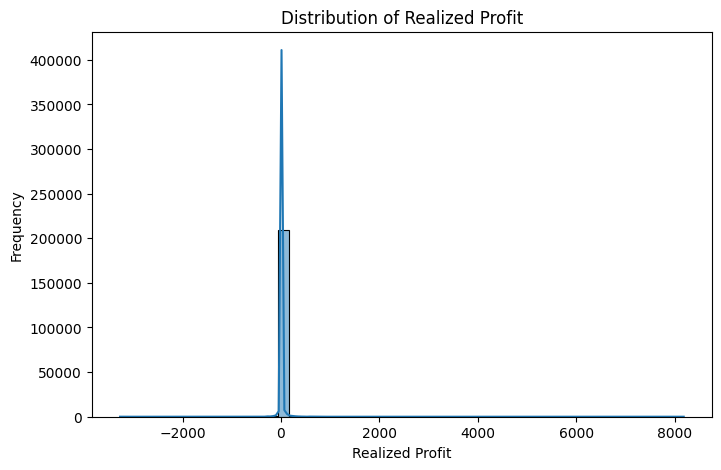

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df_final['realizedProfit'], bins=50, kde=True)
plt.title("Distribution of Realized Profit")
plt.xlabel("Realized Profit")
plt.ylabel("Frequency")
plt.show()


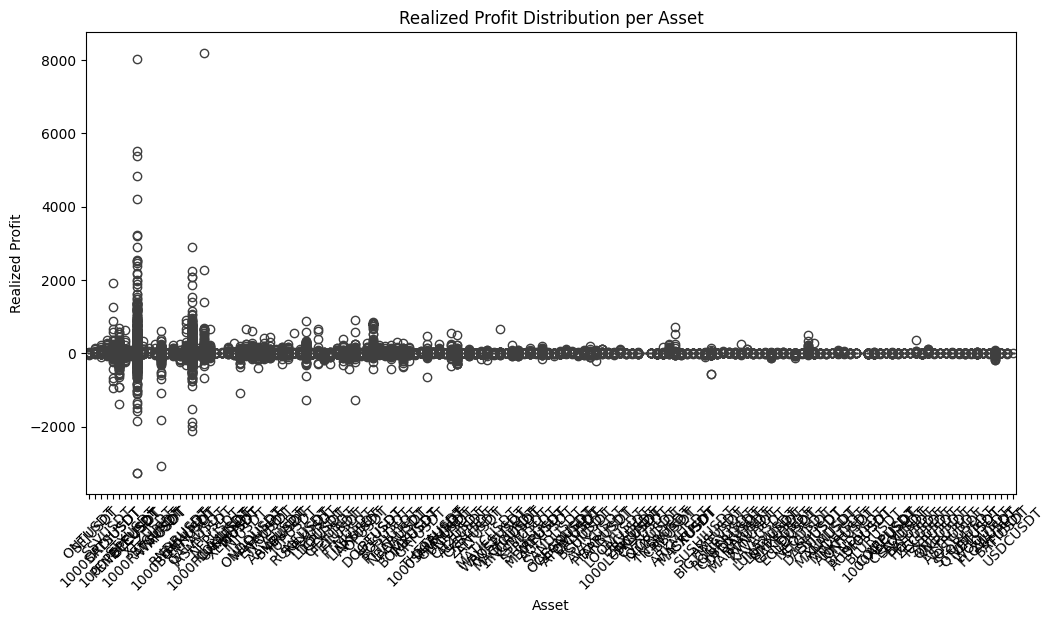

In [43]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_final['symbol'], y=df_final['realizedProfit'])
plt.title("Realized Profit Distribution per Asset")
plt.xlabel("Asset")
plt.ylabel("Realized Profit")
plt.xticks(rotation=45)
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


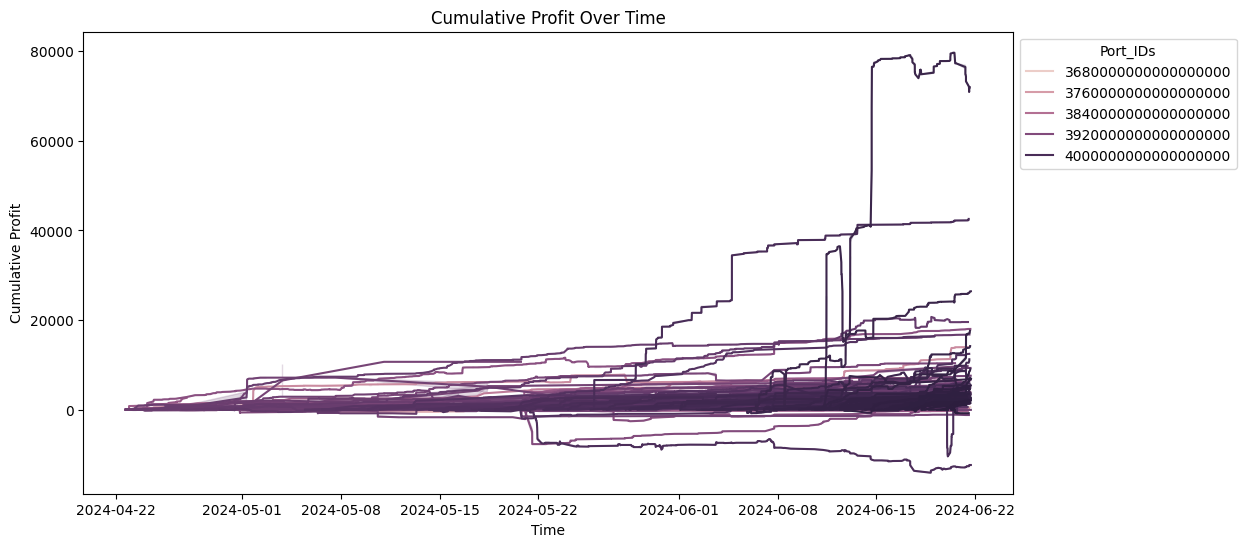

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_final, x='time', y='cumulative_profit', hue='Port_IDs')
plt.title("Cumulative Profit Over Time")
plt.xlabel("Time")
plt.ylabel("Cumulative Profit")
plt.legend(title="Port_IDs", bbox_to_anchor=(1, 1))
plt.show()


# **analysis of trading performance metrics **

<ipython-input-44-61ebbef4c2ba>:16: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df_final['MDD'] = df_final.groupby('Port_IDs')['Drawdown'].transform(min)


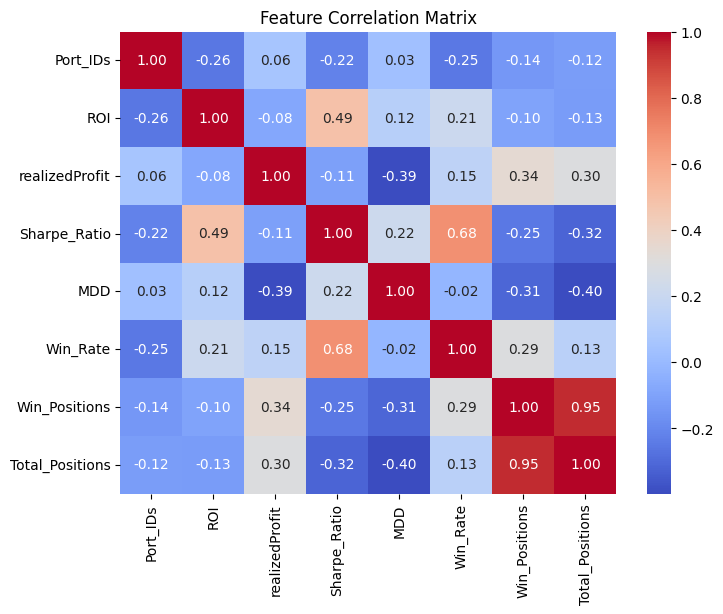

                 count          mean           std           min  \
Port_IDs         150.0  3.975655e+18  6.887470e+16  3.672755e+18   
ROI              150.0  9.488160e-03  2.519201e-02 -8.489421e-03   
realizedProfit   150.0  4.606991e+03  7.747264e+03 -1.234668e+04   
Sharpe_Ratio      29.0  8.773091e-02  1.069614e-01 -6.435393e-02   
MDD              149.0 -1.124131e+03  2.689234e+03 -2.133805e+04   
Win_Rate         150.0  3.705348e-01  1.508951e-01  0.000000e+00   
Win_Positions    150.0  5.591200e+02  7.580559e+02  0.000000e+00   
Total_Positions  150.0  1.408520e+03  1.876051e+03  1.000000e+00   
Score             29.0  1.415476e+03  3.015454e+03  1.000000e-01   

                          25%           50%           75%           max  
Port_IDs         3.943672e+18  3.998616e+18  4.029508e+18  4.041860e+18  
ROI              2.130474e-03  4.730798e-03  8.843296e-03  2.739837e-01  
realizedProfit   1.753433e+03  2.683548e+03  4.725862e+03  7.199886e+04  
Sharpe_Ratio     2.6509

In [44]:
# calculate total positions
df_final['Total_Positions'] = df_final.groupby('Port_IDs')['symbol'].transform('count')

# calculate win positions
df_final['Win_Positions'] = df_final.groupby('Port_IDs')['realizedProfit'].transform(lambda x: (x > 0).sum())

#winning trades out of the total number of trades.
df_final['Win_Rate'] = df_final['Win_Positions'] / df_final['Total_Positions']

# calculate ROI
df_final['ROI'] = df_final['realizedProfit'] / df_final['quantity']

# drop from the highest profit.
df_final['Cumulative_Max'] = df_final.groupby('Port_IDs')['cumulative_profit'].transform(lambda x: x.cummax())
df_final['Drawdown'] = df_final['cumulative_profit'] - df_final['Cumulative_Max']
df_final['MDD'] = df_final.groupby('Port_IDs')['Drawdown'].transform(min)

# sharpe Ratio(higher sharpe Ratio means better return per unit of risk.)
df_final['Sharpe_Ratio'] = df_final.groupby('Port_IDs')['daily_return'].transform(lambda x: x.mean() / (x.std() + 1e-9))

# categarizes each trade as long/short open/close based on trading behavior,
def classify_trade(row):
    if row['side'] == 'BUY' and row['positionSide'] == 'LONG':
        return 'long_open'
    elif row['side'] == 'SELL' and row['positionSide'] == 'LONG':
        return 'long_close'
    elif row['side'] == 'SELL' and row['positionSide'] == 'SHORT':
        return 'short_open'
    elif row['side'] == 'BUY' and row['positionSide'] == 'SHORT':
        return 'short_close'
    else:
        return 'unknown'

df_final['Trade_Type'] = df_final.apply(classify_trade, axis=1)


ranking_df = df_final.groupby('Port_IDs').agg({
    'ROI': 'mean',
    'realizedProfit': 'sum',
    'Sharpe_Ratio': 'mean',
    'MDD': 'min',
    'Win_Rate': 'mean',
    'Win_Positions': 'max',
    'Total_Positions': 'max'
}).reset_index()

##  correlation matrix heatmap.

correlation_matrix = ranking_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

##scoring and ranking

WEIGHTS = {
    'ROI': 0.3,
    'Sharpe_Ratio': 0.2,
    'realizedProfit': 0.2,
    'Win_Rate': 0.1,
    'MDD': 0.1
}

# calculate scores.....
ranking_df['Score'] = (
    WEIGHTS['ROI'] * ranking_df['ROI'] +
    WEIGHTS['Sharpe_Ratio'] * ranking_df['Sharpe_Ratio'] +
    WEIGHTS['realizedProfit'] * ranking_df['realizedProfit'] +
    WEIGHTS['Win_Rate'] * ranking_df['Win_Rate'] +
    WEIGHTS['MDD'] * (1 - ranking_df['MDD'])
)

# rank accounts
ranking_df = ranking_df.sort_values(by='Score', ascending=False)

# top 20 accounts
top_20 = ranking_df.head(20)

#Summary Report

summary_report = ranking_df.describe().T
print(summary_report)

# Save Results

ranking_df.to_csv("calculated_metrics.csv", index=False)
top_20.to_csv("top_20_accounts.csv", index=False)
summary_report.to_csv("summary_report.csv")


<ipython-input-45-0d7b360256b0>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_weights_df['Feature'], y=feature_weights_df['Weight'], palette="viridis")


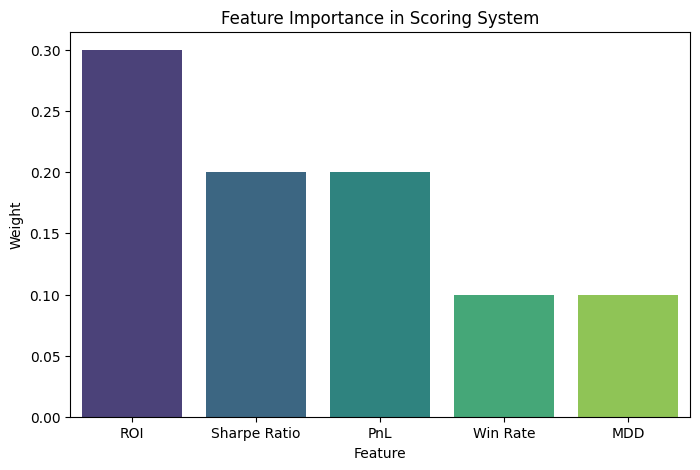

In [45]:
feature_weights = {
    'ROI': 0.3,
    'Sharpe Ratio': 0.2,
    'PnL': 0.2,
    'Win Rate': 0.1,
    'MDD': 0.1
}

# convert to DataFrame
feature_weights_df = pd.DataFrame(list(feature_weights.items()), columns=['Feature', 'Weight'])

# Plot feature,
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_weights_df['Feature'], y=feature_weights_df['Weight'], palette="viridis")
plt.title("Feature Importance in Scoring System")
plt.xlabel("Feature")
plt.ylabel("Weight")
plt.show()


In [46]:
df_final.to_csv("Trade_data.csv", index=False)